# 5.1 Convolution operation

Output for filter 1:
tensor([[-1.,  0.,  2.],
        [-2., -1.,  1.],
        [ 1.,  1., -1.]])

Output for filter 2:
tensor([[ 3., -1., -2.],
        [ 2.,  1.,  0.],
        [ 2.,  2.,  0.]])

Output for filter 3:
tensor([[ 2.,  1., -2.],
        [-2.,  2.,  1.],
        [-1., -3.,  1.]])



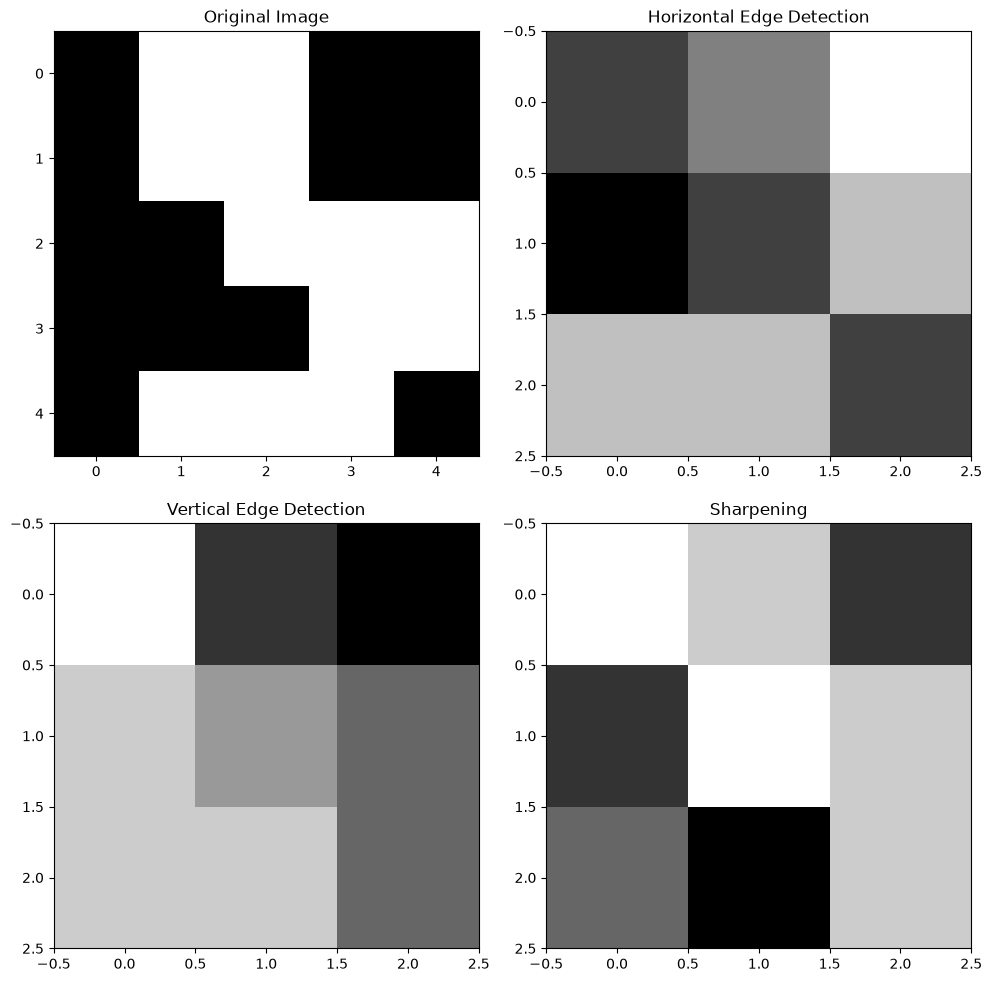

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Define a 5x5 image (grayscale) as a PyTorch tensor
image = (
    torch.tensor(
        [
            [0, 1, 1, 0, 0],
            [0, 1, 1, 0, 0],
            [0, 0, 1, 1, 1],
            [0, 0, 0, 1, 1],
            [0, 1, 1, 1, 0],
        ],
        dtype=torch.float32,
    )
    .unsqueeze(0)
    .unsqueeze(0)
)

# Define multiple 3x3 filters
filters = torch.tensor(
    [
        [[-1, -1, -1], [0, 0, 0], [1, 1, 1]],  # Horizontal edge detector
        [[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]],  # Vertical edge detector
        [[0, -1, 0], [-1, 4, -1], [0, -1, 0]],  # Sharpening filter
    ],
    dtype=torch.float32,
).unsqueeze(1)

# Apply convolution operations
outputs = []
for i, filter in enumerate(filters):
    output = F.conv2d(image, filter.unsqueeze(0))
    outputs.append(output.squeeze().detach().numpy())
    print(f"Output for filter {i+1}:")
    print(output.squeeze())
    print()

# Visualize the results
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs[0, 0].imshow(image.squeeze(), cmap='gray')
axs[0, 0].set_title('Original Image')
axs[0, 1].imshow(outputs[0], cmap='gray')
axs[0, 1].set_title('Horizontal Edge Detection')
axs[1, 0].imshow(outputs[1], cmap='gray')
axs[1, 0].set_title('Vertical Edge Detection')
axs[1, 1].imshow(outputs[2], cmap='gray')
axs[1, 1].set_title('Sharpening')
plt.tight_layout()
plt.show()

# 5.2 Pooling layer (max pooling operation)

Original Feature Map:
tensor([[1., 3., 2., 4.],
        [5., 6., 7., 8.],
        [3., 2., 1., 0.],
        [9., 5., 4., 2.]])
Pooled Output:
tensor([[6., 8.],
        [9., 4.]])


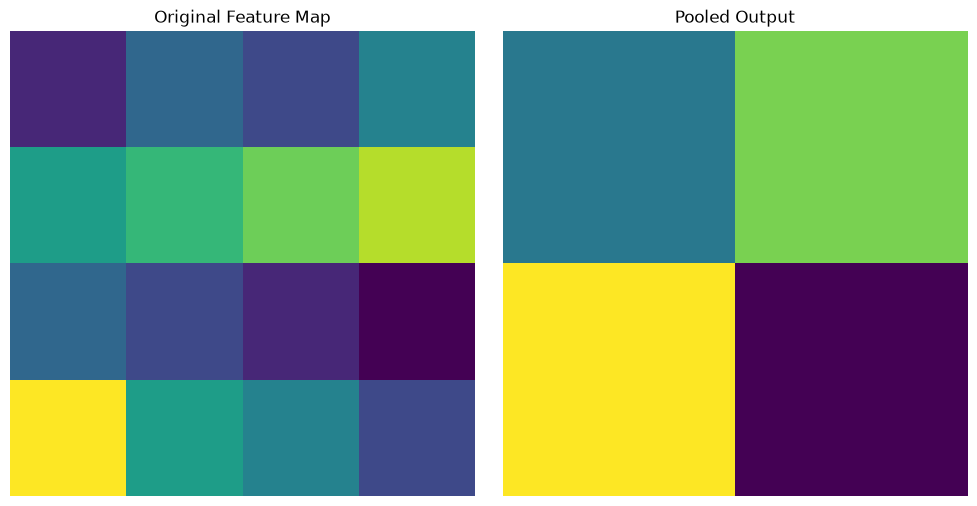

Pooled Output (stride=2):
tensor([[6., 8.],
        [9., 4.]])
Pooled Output (stride=1):
tensor([[6., 7., 8.],
        [6., 7., 8.],
        [9., 5., 4.]])


In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Define a 4x4 feature map
feature_map = (
    torch.tensor(
        [[1, 3, 2, 4], [5, 6, 7, 8], [3, 2, 1, 0], [9, 5, 4, 2]], dtype=torch.float32
    )
    .unsqueeze(0)
    .unsqueeze(0)
)
# Apply max pooling with a 2x2 kernel
pooled_output = F.max_pool2d(feature_map, kernel_size=2)
# Print the original feature map and pooled output
print("Original Feature Map:")
print(feature_map.squeeze())
print("Pooled Output:")
print(pooled_output.squeeze())
# Visualize the feature map and pooled output
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(feature_map.squeeze(), cmap="viridis")
ax1.set_title("Original Feature Map")
ax1.axis("off")
ax2.imshow(pooled_output.squeeze(), cmap="viridis")
ax2.set_title("Pooled Output")
ax2.axis("off")
plt.tight_layout()
plt.show()
# Demonstrate the effect of stride
stride_2_output = F.max_pool2d(feature_map, kernel_size=2, stride=2)
stride_1_output = F.max_pool2d(feature_map, kernel_size=2, stride=1)
print("Pooled Output (stride=2):")
print(stride_2_output.squeeze())
print("Pooled Output (stride=1):")
print(stride_1_output.squeeze())

# 5.3 ReLU activation function

In [7]:
import torch.nn.functional as F

# Define a sample feature map with both positive and negative values
feature_map = torch.tensor([[-1, 2, -3], [4, -5, 6], [-7, 8, -9]], dtype=torch.float32)

# Apply ReLU activation
relu_output = F.relu(feature_map)

# Print the output after applying ReLU
print(relu_output)

tensor([[0., 2., 0.],
        [4., 0., 6.],
        [0., 8., 0.]])
